In [19]:
# Authors: Pedro L. C. Rodrigues, Sylvain Chevallier
#
# https://github.com/plcrodrigues/Workshop-MOABB-BCI-Graz-2019

import warnings

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from mne.decoding import CSP
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis as LDA
from sklearn.pipeline import make_pipeline

import moabb
from moabb.datasets import BNCI2014_001
from moabb.evaluations import WithinSessionEvaluation
from moabb.paradigms import MotorImagery


moabb.set_log_level("info")
warnings.filterwarnings("ignore")

moabb.set_download_dir(r"C:\Users\pahan\OneDrive\Documents\Fall 2026\BMEN 600\Project\bmen-600-group-11\dataset")

In [ ]:
dataset = BNCI2014_001() # initialize the dataset that we selected
Metadata = dataset.METADATA # Access the metadata of the dataset

### Dataset Descriptions

### Participant Details

In [14]:
print(f"Number of subjects: {Metadata.participants.n_subjects}")
print(f"Health status: {Metadata.participants.health_status}")

Number of subjects: 9
Health status: healthy


### Signal Acquisition Details

In [25]:
print(f"Sampling rate: {Metadata.acquisition.sampling_rate}")
print(f"Number of channels: {Metadata.acquisition.channel_types}")
print(f"line noise frequency: {Metadata.acquisition.line_freq} Hz")
print(f"Filters Used: {Metadata.acquisition.filters}")

Sampling rate: 250.0
Number of channels: {'eeg': 22, 'eog': 3}
line noise frequency: 50.0 Hz
Filters Used: bandpass 0.5-100 Hz, 50 Hz notch


In [30]:
print(f"Paradigm: {Metadata.experiment.paradigm}")
print(f"Number of classes: {Metadata.experiment.n_classes}")
print(f"Classes: {Metadata.experiment.class_labels}")
print(f"Study Design: {Metadata.experiment.study_design}")
print(f"Trial Duration: {Metadata.experiment.trial_duration} seconds")

Paradigm: imagery
Number of classes: 4
Classes: ['left_hand', 'right_hand', 'feet', 'tongue']
Study Design: Cue-based four-class motor imagery (left hand, right hand, both feet, tongue); two sessions per subject on different days, each with 6 runs of 48 trials (288 trials per session)
Trial Duration: 4.0 seconds


### Now We know the Paradigm

In [31]:
paradigm = MotorImagery(n_classes=4) # Initialize the paradigm that we selected, in this case Motor Imagery with 4 classes

2026-10-09 13:53:08,604 WARNING MainThread moabb.paradigms.motor_imagery Choosing from all possible events


### Load The Dataset

In [6]:
X, labels, meta = paradigm.get_data(dataset=dataset)

### Verify Metadata

In [119]:
import numpy as np

classes, counts = np.unique(labels, return_counts=True)

for cls, count in zip(classes, counts):
    print(f"{cls}: {count} ({count / len(labels):.1%})")

feet: 1296 (25.0%)
left_hand: 1296 (25.0%)
right_hand: 1296 (25.0%)
tongue: 1296 (25.0%)


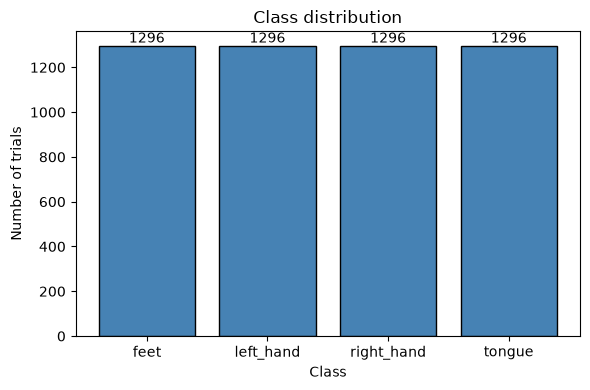

In [120]:
import numpy as np
import matplotlib.pyplot as plt

classes, counts = np.unique(labels, return_counts=True)

fig, ax = plt.subplots(figsize=(6, 4))
bars = ax.bar(classes, counts, color="steelblue", edgecolor="black")

# annotate each bar with its count
for bar, count in zip(bars, counts):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height(),
            str(count), ha="center", va="bottom")

ax.set_xlabel("Class")
ax.set_ylabel("Number of trials")
ax.set_title("Class distribution")
plt.tight_layout()
plt.show()

In [7]:
X.shape

(5184, 22, 1001)

In [8]:
meta

,subject,session,run
0,1,0train,0
1,1,0train,0
2,1,0train,0
3,1,0train,0
4,1,0train,0
...,...,...,...
5179,9,1test,5
5180,9,1test,5
5181,9,1test,5
5182,9,1test,5


# Pre Processing

## Find Noisy Trials

In [124]:
# find the trial index for the subject s session k, meta is a pandas dataframe with columns subject, session, run, and run. The index of the dataframe corresponds to the trial index in X and labels.
import numpy as np
subject = 1
session = "0train" # session 1
indices = meta[(meta.subject == subject) & (meta.session == session)].index

session_data = X[indices]

# calculate the variance of each trial and channel
variance = np.var(session_data, axis=2)
variance_total = np.sum(variance, axis=1)
variance.shape
z_score = (variance_total - np.mean(variance_total, axis=0, keepdims=True)) / np.std(variance_total, axis=0, keepdims=True)


In [125]:
indices

RangeIndex(start=0, stop=288, step=1)

In [126]:
noise_threshold = 2

Text(0, 0.5, 'Z-Score')

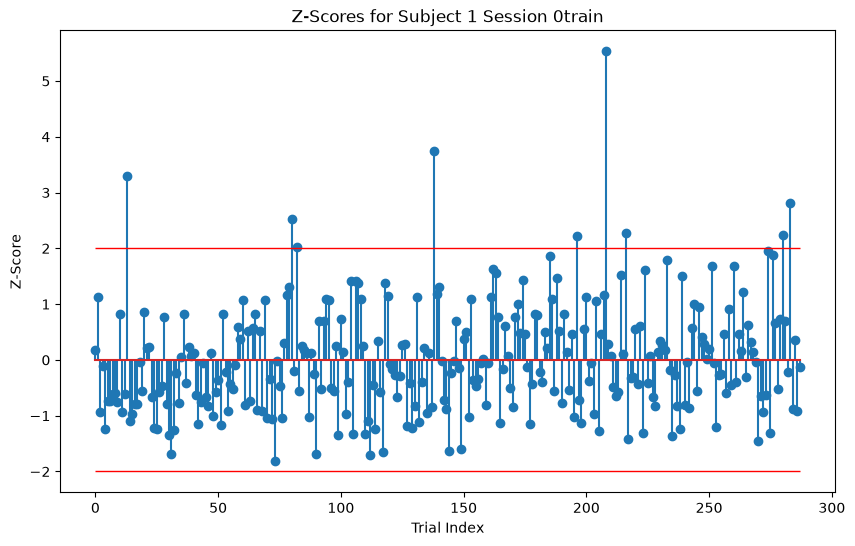

In [127]:
plt.figure(figsize=(10, 6))
plt.stem(np.arange(len(z_score)), z_score)
plt.title(f"Z-Scores for Subject {subject} Session {session}")
plt.xlabel("Trial Index")
plt.hlines(y=noise_threshold, xmin=0, xmax=len(z_score)-1, color='red', linewidth=1, alpha=1)
plt.hlines(y=-noise_threshold, xmin=0, xmax=len(z_score)-1, color='red', linewidth=1, alpha=1)
plt.ylabel("Z-Score")


In [128]:
# find noisy trials based on z-score threshold

noisy_trials = np.where(np.abs(z_score) > noise_threshold)[0]
print(f"Number of noisy trials: {len(noisy_trials)}")

# plot all channels for a noisy trial
noisy_trial_indices = indices[noisy_trials]



Number of noisy trials: 9


In [86]:
from pathlib import Path

noisy_trial_indices
# save the indices of the noisy trials to a csv file
noisy_trial_df = pd.DataFrame({'subject': subject, 'trial_index': [noisy_trial_indices]})
noisy_trial_df = pd.DataFrame({
    "subject": subject,
    "trial_index": [noisy_trial_indices]
})

csv_path = Path("noisy_trials.csv")
noisy_trial_df.to_csv(
    csv_path,
    mode="a",
    header=not csv_path.exists(),
    index=False
)

#### Plot Example Noisy EEG Trial for the Illustration 

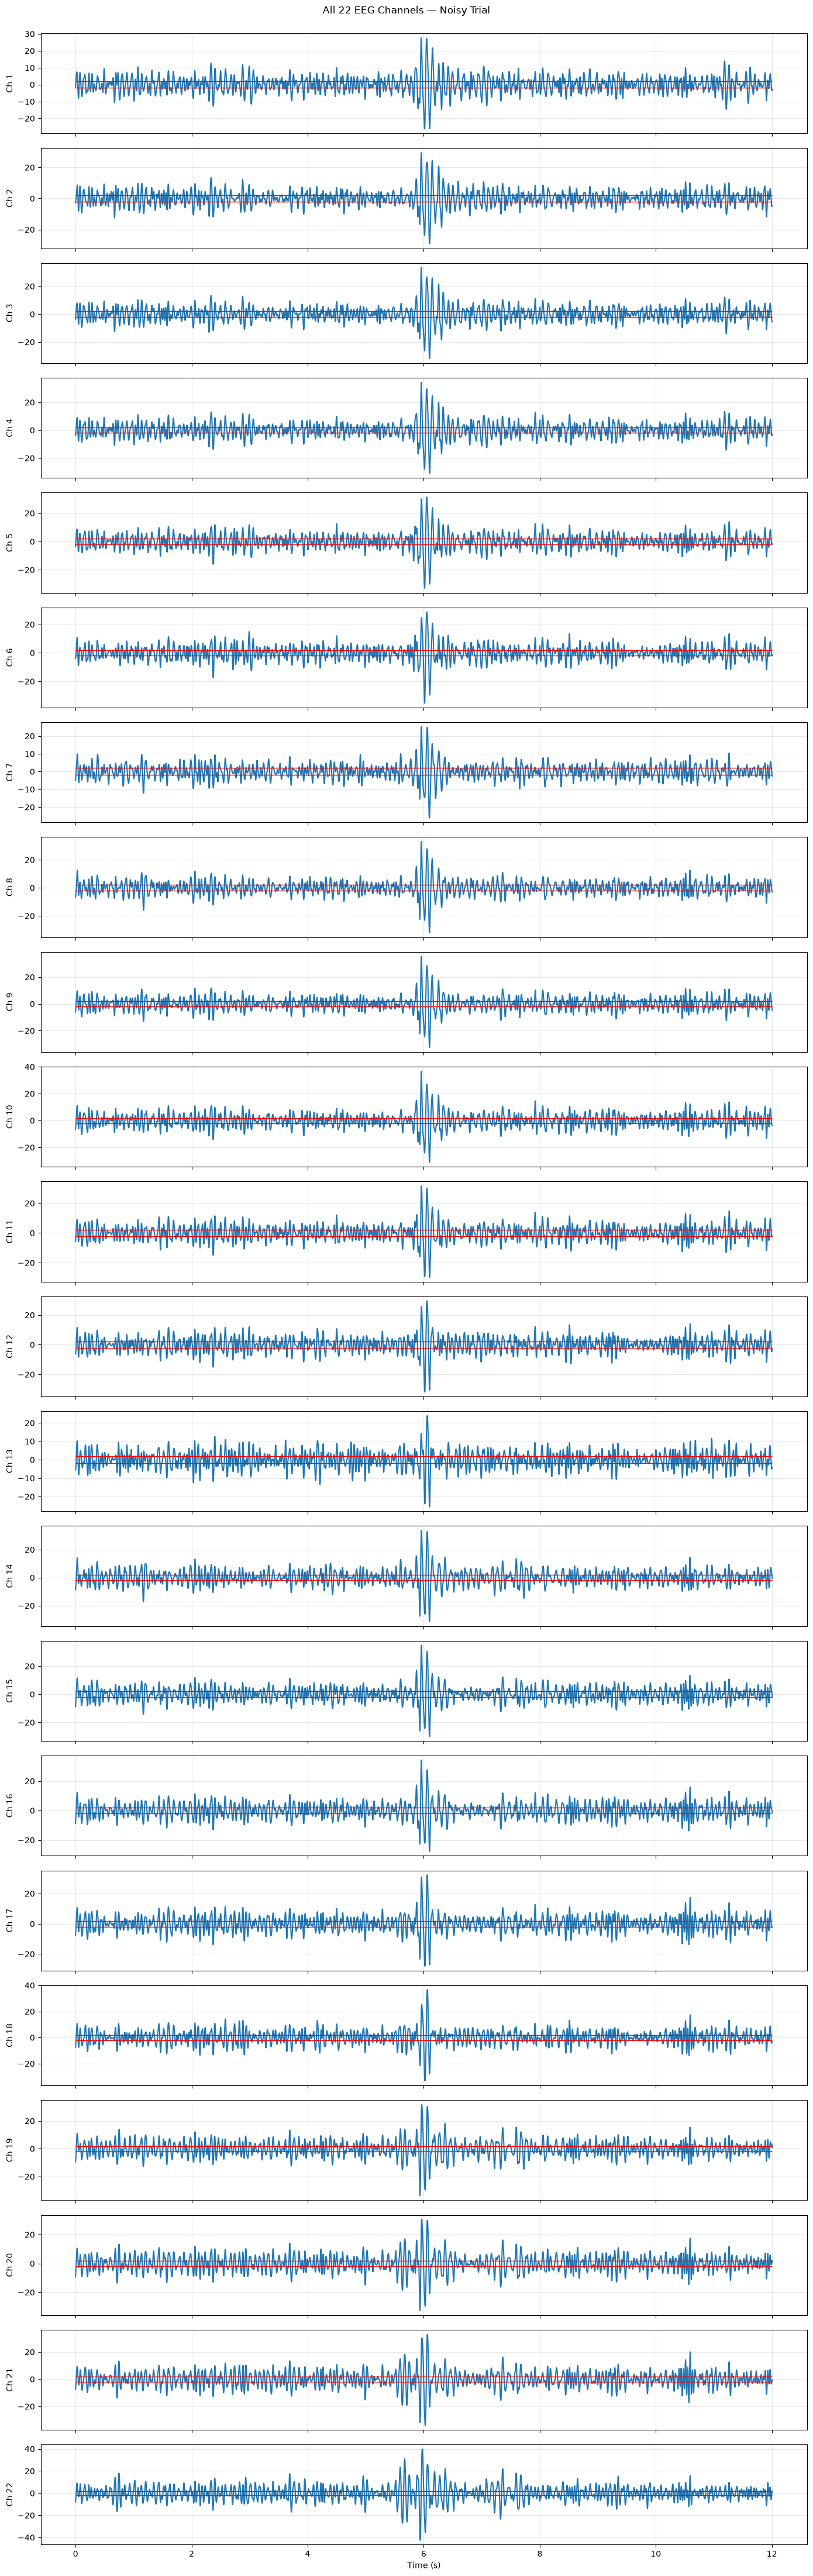

In [129]:
# Plot all EEG channels for one sample trial
import numpy as np
import matplotlib.pyplot as plt

fs = 250
trial_index = noisy_trial_indices[0]
trial_n = X[trial_index]
noisy_trial = np.concatenate([X[trial_index-1], X[trial_index], X[trial_index+1]], axis=1) # Shape: (22, number_of_samples)
n_channels = noisy_trial.shape[0]

t = np.arange(noisy_trial.shape[1]) / fs

fig, axes = plt.subplots(
    n_channels, 1,
    figsize=(14, 2 * n_channels),
    sharex=True
)

for ch in range(n_channels):
    axes[ch].plot(t, noisy_trial[ch])
    axes[ch].set_ylabel(f"Ch {ch + 1}")
    axes[ch].grid(True, alpha=0.3)
    axes[ch].hlines(xmin=t[0], xmax=t[-1], y=-noise_threshold, color='red', linewidth=1, alpha=1)
    axes[ch].hlines(xmin=t[0], xmax=t[-1], y=noise_threshold    , color='red', linewidth=1, alpha=1)

axes[-1].set_xlabel("Time (s)")
fig.suptitle("All 22 EEG Channels — Noisy Trial", y=1.0)
plt.tight_layout()
plt.show()